# Homework 1: Thinking About Data

BEE 4850/5850

**Name**: Fenya Bartram

**ID**: fdb34

> **Due Date**
>
> Friday, 2/7/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to introduce you to
simulation-based data analysis.

-   Problem 1 asks you to find an example of a spurious correlation.
-   Problem 2 asks you to explore whether a difference between data
    collected from two groups might be statistically meaningful or the
    result of noise. This problem repeats the analysis from [Statistics
    Without The Agonizing
    Pain](https://www.youtube.com/watch?v=5Dnw46eC-0o) by John Rauser
    (which is a neat watch!).
-   Problem 3 asks you to explore the impacts of selection biases on
    statistical relationships.
-   Problem 4 asks you to evaluate an interview method for finding the
    level of cheating on a test to determine whether cheating was
    relatively high or low. This problem was adapted from [Bayesian
    Methods for
    Hackers](https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/).
-   Problem 5 (only required for students in BEE 5850) asks you to
    propose several causal models for the same observational phenomenon.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.stats import pearsonr


## Problems

### Scoring

Each problem is worth 5 points.

### Problem 1

Find an example of a spurious correlation (don’t just pull from
[Spurious
Correlations!](https://www.tylervigen.com/spurious-correlations)!).

**In this problem**:

-   Describe and illustrate the correlation;
-   Explain why you think the correlation is spurious.

data from:
https://datahub.io/core/global-temp?ref=hackernoon.com 
https://trends.google.com/trends/explore?date=all&geo=US&q=aromantic&hl=en

In [ ]:
data_dir = os.path.join("Data", "flat-ui__data-Wed Feb 05 2025.csv")
temp_data = pd.read_csv(data_dir, index_col = 'Year')
temp_data = temp_data[temp_data['Source'] == 'gcag']
temp_data = temp_data.loc[2004:2023,:]

data_dir = os.path.join("Data", "search_term.csv")
search_data = pd.read_csv(data_dir, index_col = 'year')
search_data= search_data.loc[2004:2023,:]

There is a correlation between the annual global temperature anomaly and the relative interest in the term "aromantic" based on google searches (averaged by year). This is spurious as the time series have nothing to do with each other. They happen to both be increasing for the time period shown, in a somewhat exponential manner. The temperature increase is related to climate change. The increase in search terms for "aromantic" pertains to increasing levels of awareness of aromanticism.

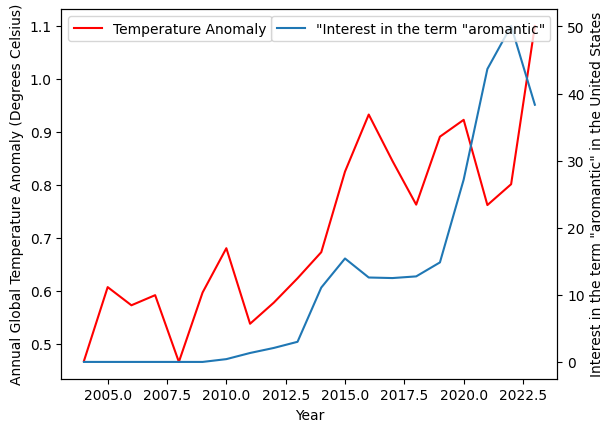

In [66]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(temp_data['Mean'], label = 'Annual Temperature Anomaly in Degrees Celsius', color = 'red')
ax2.plot(search_data['aromantic: (United States)'], label = 'Interest in the term "aromantic" in the United States')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Global Temperature Anomaly (Degrees Celsius)')
ax2.set_ylabel('Interest in the term "aromantic" in the United States')
ax.legend(['Temperature Anomaly'])
ax2.legend(['"Interest in the term "aromantic"'], loc='upper right')

In [67]:
scipy.stats.pearsonr(search_data['aromantic: (United States)'], temp_data['Mean'])

PearsonRResult(statistic=np.float64(0.6960066543732916), pvalue=np.float64(0.000653813971358644))

### Problem 2

The underlying question we would like to address is: what is the
influence of drinking beer on the likelihood of being bitten by
mosquitoes? There is a mechanistic reason why this might occur:
mosquitoes are attracted by changes in body temperature and released
CO<sub>2</sub>, and it might be that drinking beer induces these
changes. We’ll analyze this question using (synthetic) data which
separates an experimental population into two groups, one which drank
beer and the other which drank only water.

First, we’ll load data for the number of bites reported by the
participants who drank beer. This is in a comma-delimited file,
`data/bites.csv` (which is grossly overkill for this assignment). Each
row contains two columns: the group (`beer` and `water`) the person
belonged to and the number of times that person was bitten.

In Julia, we can do this using
[`CSVFiles.jl`](https://github.com/queryverse/CSVFiles.jl), which will
read in the `.csv` file into a
[`DataFrame`](https://dataframes.juliadata.org/stable/), which is a
typical data structure for tabular data (and equivalent to a Pandas
`DataFrame` in Python or a `dataframe` in R).

In [10]:
data_dir = os.path.join("Data", "bites.csv")
data = pd.read_csv(data_dir)

How can we tell if there’s a meaningful difference between the two
groups? Naively, we might just look at the differences in group means.

> **Broadcasting**
>
> The subsetting operations in the below code use `.==`, which
> “broadcasts” the element-wise comparison operator == across every
> element. The decimal in front of `==` indicates that this should be
> used element-wise (every pair of elements compared for equality,
> returning a vector of `true` or `false` values); otherwise Julia would
> try to just check for vector equality (returning a single `true` or
> `false` value).
>
> Broadcasting is a very specific feature of Julia, so this syntax would
> look different in a different programming language.

In [16]:
grouped = data.groupby(by='group').mean()
experimental_dif = grouped['bites'][0] - grouped['bites'][1]

C:\Users\fenya\AppData\Local\Temp\ipykernel_20588\4026969919.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  experimental_dif = grouped['bites'][0] - grouped['bites'][1]


This tells us that, on average, the participants in the experiment who
drank beer were bitten approximately 4.4 more times than the
participants who drank water! Does that seem like a meaningful
difference, or could it be the result of random chance?

We will use a *simulation* approach to address this question, as
follows.

-   Suppose someone is skeptical of the idea that drinking beer could
    result in a higher attraction to mosquitoes, and therefore more
    bites. To this skeptic, the two datasets are really just different
    samples from the same underlying population of people getting bitten
    by mosquitoes, rather than two different populations with different
    propensities for being bitten. This is the skeptic’s *hypothesis*,
    versus our hypothesis that drinking beer changes body temperature
    and CO<sub>2</sub> release sufficiently to attract mosquitoes.
-   If the skeptic’s hypothesis is true, then we can “shuffle” all of
    the measurements between the two datasets and re-compute the
    differences in the means. After repeating this procedure a large
    number of times, we would obtain a distribution of the differences
    in means under the assumption that the skeptic’s hypothesis is true.
-   Comparing our experimentally-observed difference to this
    distribution, we can then evaluate the consistency of the skeptic’s
    hypothesis with the experimental results.

> **Why Do We Call This A Simulation-Based Approach?**
>
> This is a simulation-based approach because the “shuffling” is a
> non-parametric way of generating new samples from the underlying
> distribution (more on this later!).
>
> The alternative to this approach is to use a statistical test, such as
> a [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), which
> [may have other
> assumptions](https://en.wikipedia.org/wiki/Student%27s_t-test#Assumptions)
> which may not be appropriate for this setting, particularly given the
> seemingly small sample sizes.

**In this problem**:

-   Conduct the above procedure to generate 50,000 simulated datasets
    under the skeptic’s hypothesis.
-   Plot a histogram of the results and add a dashed vertical line to
    show the experimental difference (if you are using Julia, feel free
    to look at the [Making Plots with Julia
    tutorial](https://viveks.me/simulation-data-analysis/tutorials/julia-plots.html)
    on the class website).
-   Draw conclusions about the plausibility of the skeptic’s hypothesis
    that there is no difference between groups. Feel free to use any
    quantitative or qualitative assessments of your simulations and the
    observed difference.

## Solution

In order to generate this simulated dataset, I determine the number of samples which involved drinking beer, in order to ensure the same size of the simulated 'beer' datasets. I then use a for loop to run through 50,000 simulated datasets. For each, I take a random sample of rows from the dataset the same length as the number of rows labeled with 'beer', and then take the remaining samples in another dataset. I then calculate the difference of the means between these datasets, and compute the difference of these means. I plot the distribution of these differences. I also estimate the percent of the samples which have at least as large of a difference in the means of the datasets (in either direction).

In [17]:
drink_num = data.groupby(by='group').count()
beer_num = drink_num['bites'].loc['beer']
difs = np.zeros(50000)
for i in range(50000):
    beer = data.sample(n=beer_num, random_state=i)
    water = data.drop(beer.index)
    difs[i] = beer['bites'].mean()-water['bites'].mean()

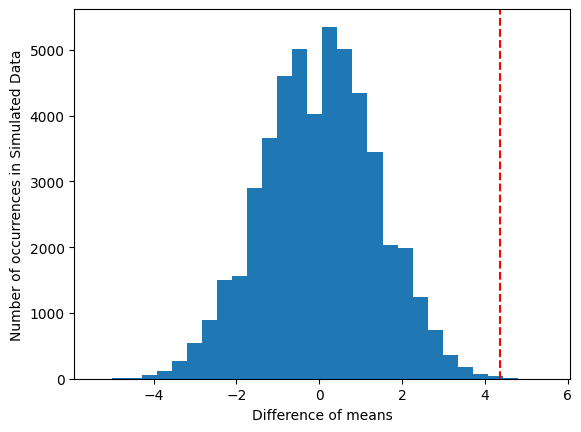

In [21]:
plt.hist(difs, bins=30)
plt.xlabel('Difference of means')
plt.ylabel('Number of occurrences in Simulated Data')
plt.axvline(x=experimental_dif, color='r', linestyle='--')

In [34]:
(sum(difs >= experimental_dif)+sum(difs <= -experimental_dif))/len(difs)

np.float64(0.00084)


The skeptic's hypothesis does not seem plausible, because there are few samples which result in a difference between the means at least as large as what was observed in the experiment. In particular, only .084% of the samples resulted in a difference at least as large as what was observed. Thus, it is unlikely that the two samples came from the same dataset and happened to have such a difference based on chance.

### Problem 3

A scientific funding agency receives 200 proposals in response to a
call. The panel is asked to evaluate each proposal on two criteria:
scientific rigor and potential impact (or “newsworthiness”). After
standardizing each of these scores to independently follow a standard
normal distribution ($\text{Normal}(0, 1)$), the two standardized scores
are summed to get the total score for the proposal. Based on these total
scores, the top 10% of the proposals are selected for funding.

A researcher who is studying the relationship between rigor and impact
has used data on the funded proposals to claim high-impact proposals are
necessarily less rigorous, and indeed found a statistically significant
negative correlation between the rigor and impact scores for the funded
proposals. You are more skeptical and believe this effect is an artifact
from the selection process, which would make the claim a bit ironic.

**In this problem**:

-   Create a generative model for the grant-selection procedure under
    the null assumption of no correlation between rigor and impact. You
    can sample rigor and impact scores directly from
    $\text{Normal}(0, 1)$.
-   Using 1,000 simulations, compare the distribution of correlations
    between rigor and impact for the funded proposals to the general
    proposal population.
-   Explain why, when conditioning on selection for funding, there might
    be a negative correlation between rigor and impact even when none
    generally exists.

> **Selection-Distortion Effects**
>
> These **selection-distortion effects** are pretty common in
> observational data, going back to [work by Dawes in the 1970s on the
> lack of predictive ability of admission variables on student
> success](https://www.science.org/doi/abs/10.1126/science.187.4178.721)
> and including [studies claiming to identify a causal fingerprint of
> genes on
> outcomes](https://www.nature.com/articles/s41598-021-89020-x).
>
> This is, of course, just one example of how not thinking carefully
> about data-generating processes can fundamentally contaminate
> statistical analyses, emphasizing that **data do not have meaning
> absent a model for how they were generated**.

## Solution 

I take 1000 independent samples from Normal (0,1) to represent the rigor category, and 1000 to represent the impact category. I calculate the Pearson correlation coefficient and associated p-value to determine if there is a statistically significant correlation. Next, I add up the rigor and impact categories for each sample, and then take the top 10 percent in terms of sum. I again find the Pearson correlation coefficient and associated p-value, this time looking only at those values with a sum in the top 10%.

In [43]:
# general proposal population
mu, sigma = 0, 1 # mean and standard deviation
rigor = np.random.normal(mu, sigma, 1000)
impact = np.random.normal(mu, sigma, 1000)
scipy.stats.pearsonr(rigor, impact)

PearsonRResult(statistic=np.float64(0.011618899582961138), pvalue=np.float64(0.7136378816896729))

In [45]:
sum_score = rigor+impact
rigor_selected = rigor[sum_score > np.percentile(sum_score, 90)]
impact_selected = impact[sum_score > np.percentile(sum_score, 90)]
scipy.stats.pearsonr(rigor_selected, impact_selected)

PearsonRResult(statistic=np.float64(-0.7322898151551513), pvalue=np.float64(4.839978370709214e-18))

Looking at the general proposal population, there does not appear to be a statistically significant correlation between the rigor and impact, which is expected since they are independent distributions. However, taking only those samples with the top 10% of sums, there does appear to be a negative statically significant correlation. Thus, even if the underlying distributions were independent, a negative correlation may be observed in the selected samples. Since the sum is taken, lower scores in one category can be compensated by higher scores in another category when choosing which to select. For instance, an article which did not score exceptionally highly for rigor would be more likely to be selected if it did score exceptionally highly for impact. While those which scored highly for both categories would be more likely to be selected, these will be relatively rare since they are in the tail for both distributions.

### Problem 4

You are trying to detect how prevalent cheating was on an exam. You are
skeptical of the efficacy of just asking the students if they cheated.
You are also concerned about privacy — your goal is not to punish
individual students, but to see if there are systemic problems that need
to be addressed. Someone proposes the following interview procedure,
which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

We have a hypothesis that cheating was not prevalent, and the proportion
of cheaters was no more than 5% of the class; in other words, we expect
5 “true” cheaters out of a class of 100 students. Our TA is more jaded
and thinks that cheating was more rampant, and that 30% of the class
cheated. The proposed interview procedure is noisy: the interviewer does
not know if an admission means that the student cheated, or the result
of a heads. However, it gives us a data-generating process that we can
model and analyze for consistency with our hypothesis and that of the
TA.

**In this problem**:

-   Derive and code a simulation model for the above interview procedure
    given the “true” probability of cheating $p$.
-   Simulate your model (for a class of 100 students) 50,000 times under
    a null hypothesis of no cheating, your hypothesis of 5% cheating,
    the TA’s hypothesis of 30% cheating, and plot the resulting
    datasets.
-   If you received 31 “Yes, I cheated” responses while interviewing
    your class, what could you conclude?
-   How useful do you think the interview procedure is to identify
    systemic cheating? What changes to the design might you make?

## Solution

I use a for loop to run through 50,000 simulations. For each simulation, I use a random binomial distribution with a probability of 50% to simulate the first coin flip 100 times. This gives the number of heads. I then draw this number of samples from another binomial, this time with a probability of p (the assumed true probability of cheating) to simulate the number of reported cheating as a result of telling the truth. I take 100 minus the number of heads as the number of tails, and draw this many samples from another binomial distribution with a probability of 50% to simulate the second coin flips, and take the result of these to be the number of times cheating would be reported as a result of the procedure. Adding up the number of times cheating was reported when heads was rolled to when tails was rolled, I obtain the total number of times cheating was reported.

Text(0.5, 1.0, 'Distribution of Reported Cheating for 0% True Cheating')

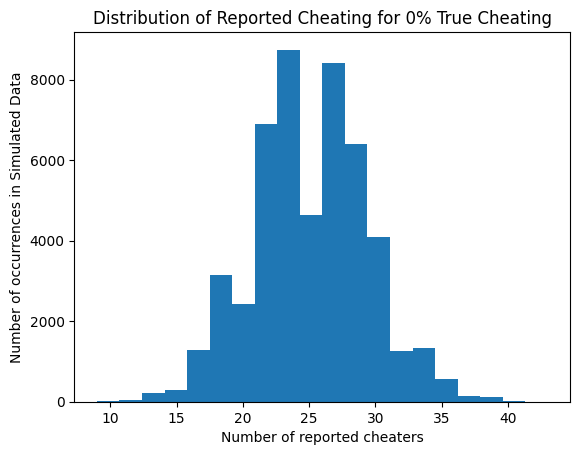

In [46]:
# 50% cheating
p = 0
cheats = np.zeros(50000)

for i in range(50000):
    heads = np.random.binomial(100, 0.5, size=None)
    cheats[i] = np.random.binomial(heads, p, size=None) + np.random.binomial(100-heads, 0.5, size=None)

plt.hist(cheats, bins=20)
plt.xlabel('Number of reported cheaters')
plt.ylabel('Number of occurrences in Simulated Data')
plt.title('Distribution of Reported Cheating for 0% True Cheating')
# plt.axvline(x=experimental_dif, color='r', linestyle='--')

In [6]:
np.std(cheats)

np.float64(4.320298552229927)

In [28]:
sum(cheats >= 31)/len(cheats)

np.float64(0.10182)

Text(0, 0.5, 'Number of occurrences in Simulated Data')

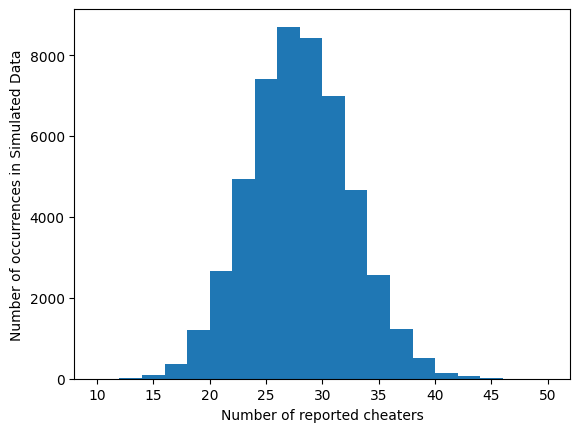

In [ ]:
# 5% cheating
p = 0.05
cheats = np.zeros(50000)

for i in range(50000):
    heads = np.random.binomial(100, 0.5, size=None)
    cheats[i] = np.random.binomial(heads, p, size=None) + np.random.binomial(100-heads, 0.5, size=None)
    
plt.hist(cheats, bins=20)
plt.xlabel('Number of reported cheaters')
plt.ylabel('Number of occurrences in Simulated Data')
plt.title('Distribution of Reported Cheating for 5% True Cheating')

In [31]:
sum(cheats >= 31)/len(cheats)

np.float64(0.24794)

Text(0, 0.5, 'Number of occurrences in Simulated Data')

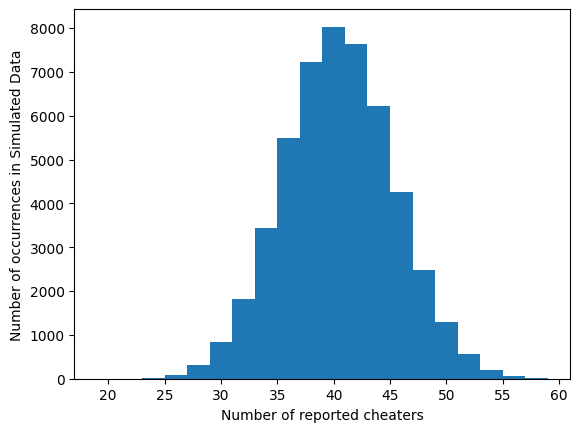

In [32]:
# 50% cheating
p = 0.3
cheats = np.zeros(50000)

for i in range(50000):
    heads = np.random.binomial(100, 0.5, size=None)
    cheats[i] = np.random.binomial(heads, p, size=None) + np.random.binomial(100-heads, 0.5, size=None)

plt.hist(cheats, bins=20)
plt.xlabel('Number of reported cheaters')
plt.ylabel('Number of occurrences in Simulated Data')
plt.title('Distribution of Reported Cheating for 30% True Cheating')
# plt.axvline(x=experimental_dif, color='r', linestyle='--')

In [33]:
sum(cheats <= 31)/len(cheats)

np.float64(0.04016)

Text(0, 0.5, 'Number of occurrences in Simulated Data')

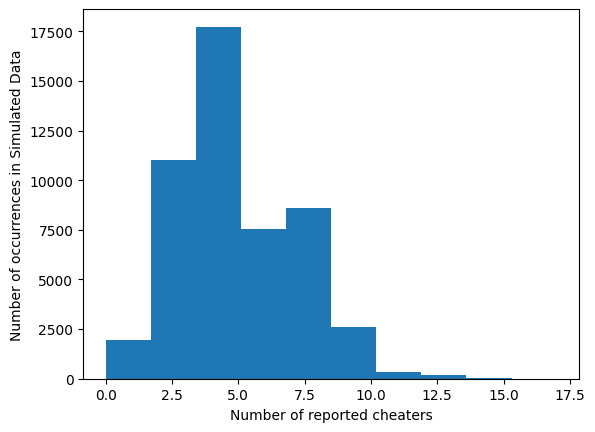

In [ ]:
# 50% cheating
p = 0
cheats = np.zeros(50000)

for i in range(50000):
    heads = np.random.binomial(100, 0.5, size=None)
    cheats[i] = np.random.binomial(heads, p, size=None) + np.random.binomial(100-heads, 0.1, size=None)

plt.hist(cheats, bins=20)
plt.xlabel('Number of reported cheaters')
plt.ylabel('Number of occurrences in Simulated Data')
plt.title('Distribution of Reported Cheating for 0% True Cheating with Reduced Reports of Cheating')
# plt.axvline(x=experimental_dif, color='r', linestyle='--')

In [8]:
np.std(cheats)

np.float64(2.189741083416028)

Under the null hypothesis (no cheating), 31 or more instances of reported cheating were found to occur around 10% of the time. Under the 5% cheating hypothesis, 31 or more instances of reported cheating were found to occur around 25% of the time. Under the 30% cheating hypothesis, 31 or less instances of reported cheating were found to occur around 4% of the time. Thus, 31 reports of cheating is more consistent with a cheating rate of 5% than 0% or 30%. However, values this extreme do appear when the probability is 0% and 30% as well, so it is difficult to come to a firm conclusion.

The design is not very useful in that it does not provide clear evidence of cheating, since values as large as the observed do appear under the null for about 10% of simulations. One change to the design could be to reduce the number of people who reported cheating when the first coin comes up as tails. For instance, they could flip a coin twice more and only report cheating if both came up heads. This would reduce the standard deviation of the distribution, potentially reducing the percentage expected to be as large under the null hypothesis, while still having some false reports of cheating in order to protect student's privacy and convince them to tell the truth if indicated by the procedure.


### Problem 5

**This problem is only required for students in BEE 5850**.

Adjusting for inflation, there has been an increase in tropical cyclone
damages on the U.S. Atlantic coast between 1900 and 2022 (see
<a href="#fig-tc" class="quarto-xref">Figure 1</a>).

<figure id="fig-tc">
<img src="attachment:figures/normalized-TC-damages.jpg" />
<figcaption>Figure 1: Change in tropical cyclone damages in U.S.
Atlantic coastal counties from 1900–2022, aggregated by pentad and
normalized to 2018 U.S. dollars. The red line shows an exponential trend
of 1.06%/yr growth in damages. Reproduced from <a
href="https://doi.org/10.1175/JAMC-D-24-0047.1">Willoughby, Hernandez,
&amp; Pinnock (2024)</a>.</figcaption>
</figure>

**In this problem**:

-   Describe two different mechanisms by which tropical cyclone damages
    in coastal counties might have increased over this period.
-   How might you propose to examine the relative strengths of these
    mechanisms? You don’t need to actually do this (this is indeed a
    somewhat thorny debate in the literature), but think about potential
    modeling and data approaches.

One mechanism by which tropical cyclone damages in coastal counties might have increased is due to climate change leading to increases in the frequency and severity of cyclones. Another is due to people building in areas which are more susceptible to cyclones, due to factors such as the "levee effect", when people feel more protected due to flood protection projects which leads them to build more in coastal areas, and ends up increasing risk.


The first mechanism could be tested using climate models to estimate the damage caused by cyclones in the current conditions compared to those in a counterfactual which did not include climate change. This could build on current detection and attribution methods, while also seeking to estimate the additional costs incurred by the changes attributed to climate change.


The second mechanism could be studied by looking at the amount of infrastructure built in coastal areas susceptible to tropical cyclones, to estimate if this amount is increasing. One could simulate how much damage would have occurred as a result of the coastal storms had this area remained constant.

## References

http://wwwens.aero.jussieu.fr/lefrere/master/SPE/docs-python/scipy-doc/generated/scipy.stats.pearsonr.html#:~:text=The%20p%2Dvalue%20roughly%20indicates,larger%20than%20500%20or%20so.

https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

https://numpy.org/doc/2.1/reference/random/generated/numpy.random.binomial.html